# Plotting TRF Analysis

By using pearson's correlation, we are able to determine if there's a statistical significance in the TRF analysis performed on the DiLiberti 2021 dataset

In [1]:
# Confirm file location in order to determine how to source in pickle files 
! pwd


/Users/arianapereira/Documents/Masters/Projects/SigMA/musical-surprisal/TRF


In [13]:
import pickle
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import eelbrain
from eelbrain import combine

### Defining Plotting Functions

In [3]:
def plot_boxplot(ax, vals, p_value, ylabel):
    bp = ax.boxplot([vals], positions=[0], widths=0.6, patch_artist=True,
                    showfliers=False, medianprops=dict(visible=False))
    bp['boxes'][0].set_facecolor('lightblue')
    ax.hlines(np.mean(vals), -0.3, 0.3, colors='red', linewidth=1.5)

    # Add significance stars if p < 0.05
    if p_value < 0.05:
        # Get the maximum whisker value for consistent positioning
        whisker_max = bp['whiskers'][1].get_ydata()[1]
        
        # Fixed offset from the highest whisker
        y_pos = whisker_max + 0.055
        
        # Draw buckets
        ax.plot([-0.3, -0.3, 0.3, 0.3], [y_pos-0.005, y_pos, y_pos, y_pos-0.005], 'k-', linewidth=1)
        
        # Add stars
        if p_value < 0.001:
            stars = '***'
        elif p_value < 0.01:
            stars = '**'
        else:
            stars = '*'
            
        ax.text(0, y_pos+0.005, stars, ha='center', va='bottom', fontsize=18)

    ax.set_xticks([0])
    ax.set_xticklabels(['All Subjects'], fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_ylim(-0.1, 0.30)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(True, alpha=0.3)


def plot_violin(ax, vals, p_value, ylabel):
    parts = ax.violinplot([vals], positions=[0], widths=0.6, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('lightblue')
        pc.set_alpha(0.7)
    ax.hlines(np.mean(vals), -0.3, 0.3, colors='red', linewidth=1.5)

    # Add significance stars if p < 0.05
    if p_value < 0.05:
        y_pos = np.max(vals) + 0.02

        ax.plot([-0.3, -0.3, 0.3, 0.3], [y_pos - 0.005, y_pos, y_pos, y_pos - 0.005], 'k-', linewidth=1)

        if p_value < 0.001:
            stars = '***'
        elif p_value < 0.01:
            stars = '**'
        else:
            stars = '*'
        ax.text(0, y_pos + 0.005, stars, ha='center', va='bottom', fontsize=18)

    ax.set_xticks([0])
    ax.set_xticklabels(['All Subjects'], fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_ylim(-0.1, 0.30)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(True, alpha=0.3)
    
def plot_musician_boxplot(ax, nm_vals, m_vals, p_value, ylabel):
    bp1 = ax.boxplot([nm_vals], positions=[0], widths=0.6, patch_artist=True, showfliers=False, medianprops=dict(visible=False))
    bp1['boxes'][0].set_facecolor('lightblue')
    ax.hlines(np.mean(nm_vals), -0.3, 0.3, colors='red', linewidth=1.5)

    bp2 = ax.boxplot([m_vals], positions=[1], widths=0.6, patch_artist=True, showfliers=False, medianprops=dict(visible=False))
    bp2['boxes'][0].set_facecolor('lightgreen')
    ax.hlines(np.mean(m_vals), 0.7, 1.3, colors='red', linewidth=1.5)

    # Add significance stars if p < 0.05
    if p_value < 0.05:
        # Get the maximum whisker value for consistent positioning
        whisker_max_nm = bp1['whiskers'][1].get_ydata()[1]
        whisker_max_m = bp2['whiskers'][1].get_ydata()[1]
        max_whisker = max(whisker_max_nm, whisker_max_m)
        
        # Fixed offset from the highest whisker
        y_pos = max_whisker + 0.055
        
        # Draw buckets
        ax.plot([0, 0, 1, 1], [y_pos-0.005, y_pos, y_pos, y_pos-0.005], 'k-', linewidth=1)
        
        # Add stars
        if p_value < 0.001:
            stars = '***'
        elif p_value < 0.01:
            stars = '**'
        else:
            stars = '*'
            
        ax.text(0.5, y_pos+0.005, stars, ha='center', va='bottom', fontsize=18)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Musicians', 'Musicians'], fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_ylim(-0.1, 0.60)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(True, alpha=0.3)
    
    
def plot_musician_violin(ax, nm_vals, m_vals, p_value, ylabel):
    parts1 = ax.violinplot([nm_vals], positions=[0], widths=0.6, showextrema=False)
    for pc in parts1['bodies']:
        pc.set_facecolor('lightblue')
        pc.set_alpha(0.7)
    ax.hlines(np.mean(nm_vals), -0.3, 0.3, colors='red', linewidth=1.5)

    parts2 = ax.violinplot([m_vals], positions=[1], widths=0.6, showextrema=False)
    for pc in parts2['bodies']:
        pc.set_facecolor('lightgreen')
        pc.set_alpha(0.7)
    ax.hlines(np.mean(m_vals), 0.7, 1.3, colors='red', linewidth=1.5)

    # Add significance stars if p < 0.05
    if p_value < 0.05:
        max_nm = np.max(nm_vals)
        max_m = np.max(m_vals)
        y_pos = max(max_nm, max_m) + 0.02

        ax.plot([0, 0, 1, 1], [y_pos - 0.005, y_pos, y_pos, y_pos - 0.005], 'k-', linewidth=1)

        if p_value < 0.001:
            stars = '***'
        elif p_value < 0.01:
            stars = '**'
        else:
            stars = '*'
        ax.text(0.5, y_pos + 0.005, stars, ha='center', va='bottom', fontsize=18)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Musicians', 'Musicians'], fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_ylim(-0.1, 0.60)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(True, alpha=0.3)

# Decoder Correlation Analysis
In the plots below, we are analyzing if there is a statistically signficant difference between musicians and non musicians when comparing the correlation of TRF decoded neural signals to the real recorded EEG. 

**Decoding** (<i>EEG → stimulus</i>): `decoder` and `decoder_onsets`. The model takes **EEG and reconstructs the audio feature**.

- The model asks: <i>"Given the EEG, can we reconstruct what the person was listening to?"</i>
- The decoder weights are **not directly neurophysiologically interpretable**, they are optimized for reconstruction, not for reflecting brain responses
- The `r` value tells you **how much of the stimulus can be recovered from brain activity**
- Good for measuring **how strongly the brain is tracking the stimulus** overall, and useful for clinical/BCI applications

To decode the TRF signal, 4 features were evaluated and informed the TRF modeling. These features include:

- **Envelope** - specifically the hilbert envelope of the audio stimulus (per `.envelope()` method in eelbrain)  
- **Onsets** - for each audio envelope, it finds where the sound gets louder (rising edges), discarding the parts where it gets quieter or stays flat
- **Surprisal** - as calculated by the IDyOMpy model (a statistical model using Markov Chains) and represents the unexpected-ness of pitch and note length)
- **Entropy** - as calculated by IDyOMpy model and represents the general information content at any point in time in the song (i.e. how certain we are anticipating the next note of a song)

## Inspecting Data for One Subject

In [23]:
filename = f"pickles/Sub19_['envelope', 'onsets', 'surprisal', 'entropy']_all_data.pkl"
data = eelbrain.load.unpickle(filename)
df = pd.DataFrame(data)
df

,trf,trf_cv,decoder,decoder_onsets,trials
trial0,<BoostingResult eeg ~ envelope + onsets + surp...,<BoostingResult eeg ~ envelope + onsets + surp...,"<BoostingResult envelope ~ eeg, -0.6 - 0.2, er...","<BoostingResult onsets ~ eeg, -0.6 - 0.2, erro...","{'y_pred': [0.186911102880433, 0.1406203055930..."
trial1,<BoostingResult eeg ~ envelope + onsets + surp...,<BoostingResult eeg ~ envelope + onsets + surp...,"<BoostingResult envelope ~ eeg, -0.6 - 0.2, er...","<BoostingResult onsets ~ eeg, -0.6 - 0.2, erro...","{'y_pred': [-0.6925483506784307, -2.6548884344..."
trial2,<BoostingResult eeg ~ envelope + onsets + surp...,<BoostingResult eeg ~ envelope + onsets + surp...,"<BoostingResult envelope ~ eeg, -0.6 - 0.2, er...","<BoostingResult onsets ~ eeg, -0.6 - 0.2, erro...","{'y_pred': [0.740870092175725, 2.1673279367262..."
trial3,<BoostingResult eeg ~ envelope + onsets + surp...,<BoostingResult eeg ~ envelope + onsets + surp...,"<BoostingResult envelope ~ eeg, -0.6 - 0.2, er...","<BoostingResult onsets ~ eeg, -0.6 - 0.2, erro...","{'y_pred': [0.8873369365304816, 1.928545467551..."
trial4,<BoostingResult eeg ~ envelope + onsets + surp...,<BoostingResult eeg ~ envelope + onsets + surp...,"<BoostingResult envelope ~ eeg, -0.6 - 0.2, er...","<BoostingResult onsets ~ eeg, -0.6 - 0.2, erro...","{'y_pred': [1.2226275086722729, -2.44779231527..."
trial5,<BoostingResult eeg ~ envelope + onsets + surp...,<BoostingResult eeg ~ envelope + onsets + surp...,"<BoostingResult envelope ~ eeg, -0.6 - 0.2, er...","<BoostingResult onsets ~ eeg, -0.6 - 0.2, erro...","{'y_pred': [0.042276368328269025, 0.6367185953..."
trial6,<BoostingResult eeg ~ envelope + onsets + surp...,<BoostingResult eeg ~ envelope + onsets + surp...,"<BoostingResult envelope ~ eeg, -0.6 - 0.2, er...","<BoostingResult onsets ~ eeg, -0.6 - 0.2, erro...","{'y_pred': [-0.15187064271746226, 4.5182789635..."
trial7,<BoostingResult eeg ~ envelope + onsets + surp...,<BoostingResult eeg ~ envelope + onsets + surp...,"<BoostingResult envelope ~ eeg, -0.6 - 0.2, er...","<BoostingResult onsets ~ eeg, -0.6 - 0.2, erro...","{'y_pred': [-0.16318229301037376, 0.1704279562..."
trial8,<BoostingResult eeg ~ envelope + onsets + surp...,<BoostingResult eeg ~ envelope + onsets + surp...,"<BoostingResult envelope ~ eeg, -0.6 - 0.2, er...","<BoostingResult onsets ~ eeg, -0.6 - 0.2, erro...","{'y_pred': [-1.503814369595689, -2.44104857783..."
trial9,<BoostingResult eeg ~ envelope + onsets + surp...,<BoostingResult eeg ~ envelope + onsets + surp...,"<BoostingResult envelope ~ eeg, -0.6 - 0.2, er...","<BoostingResult onsets ~ eeg, -0.6 - 0.2, erro...","{'y_pred': [0.017304106546832135, 0.0781062749..."


We stored the following TRF outputs:

|    Variable   |                                               What it is                                              |
|:-------------|:-----------------------------------------------------------------------------------------------------|
| y_pred        | The envelope predicted from EEG by convolving the envelope decoder with the EEG signal                |
| y             | The actual envelope of the audio stimulus (normalized)                                                |
| r             | Pearson correlation between y and y_pred — measures how well EEG can reconstruct the envelope         |
| y_onsets      | The actual acoustic onsets signal (normalized)                                                        |
| y_pred_onsets | The onsets predicted from EEG by convolving the onsets decoder with EEG                               |
| r_onsets      | Pearson correlation between y_onsets and y_pred_onsets — measures how well EEG can reconstruct onsets |

In [21]:
# Display an example of what trial data contains for 1 trial
data['trials']['trial0']

{'y_pred': <NDVar 'predicted envelope': 15804 time>,
 'y': <NDVar 'envelope': 15804 time>,
 'r': 0.2884857592988741,
 'y_pred_onsets': <NDVar 'predicted onsets': 15804 time>,
 'y_onsets': <NDVar 'onsets': 15804 time>,
 'r_onsets': 0.20179847487294922}

## Plot Correlation Analysis for One Example Subject

Envelope  | mean r = 0.206, std = 0.076
Onsets    | mean r = 0.126,   std = 0.052


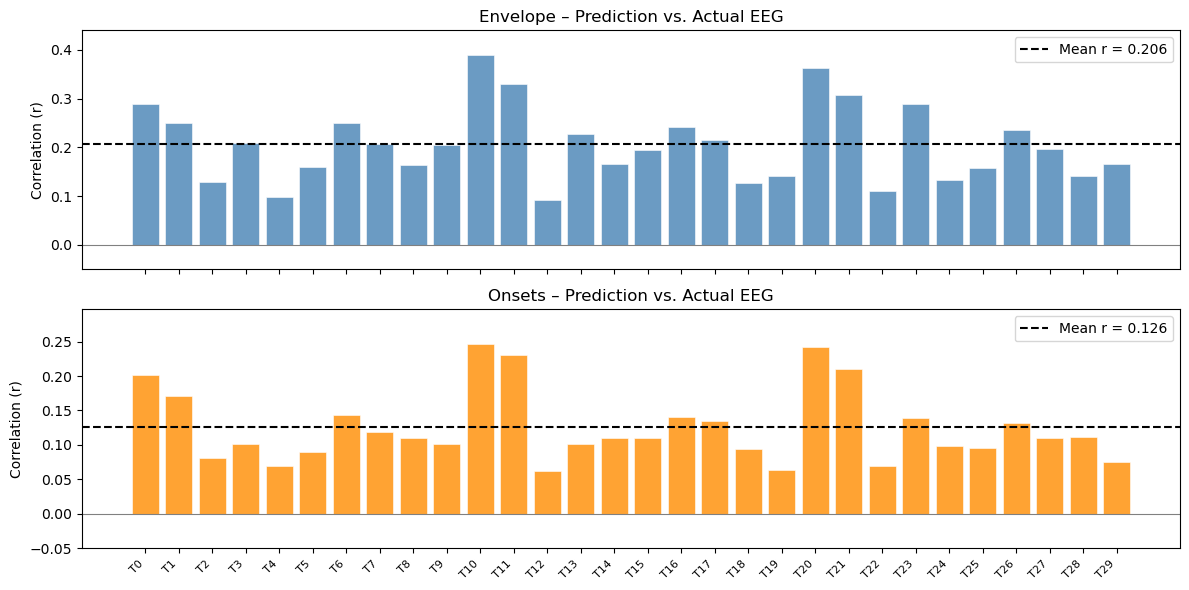

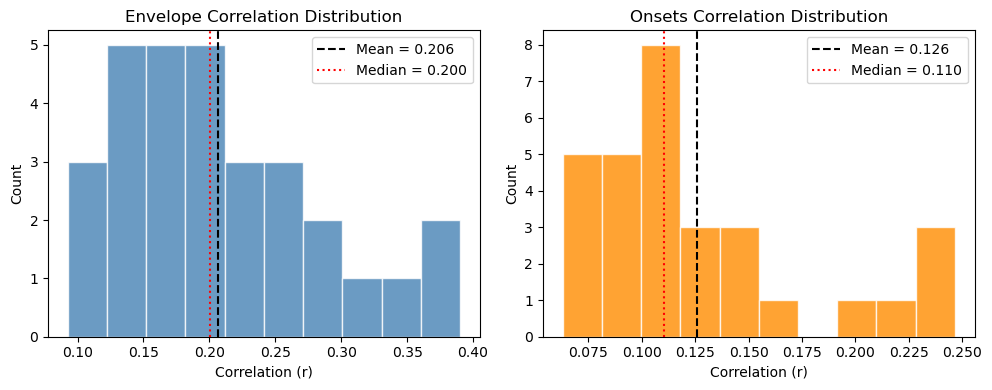

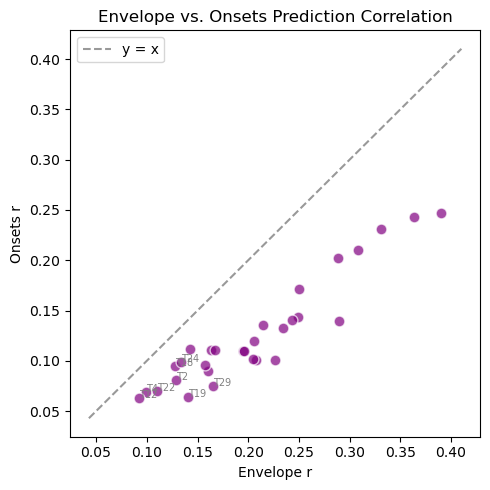

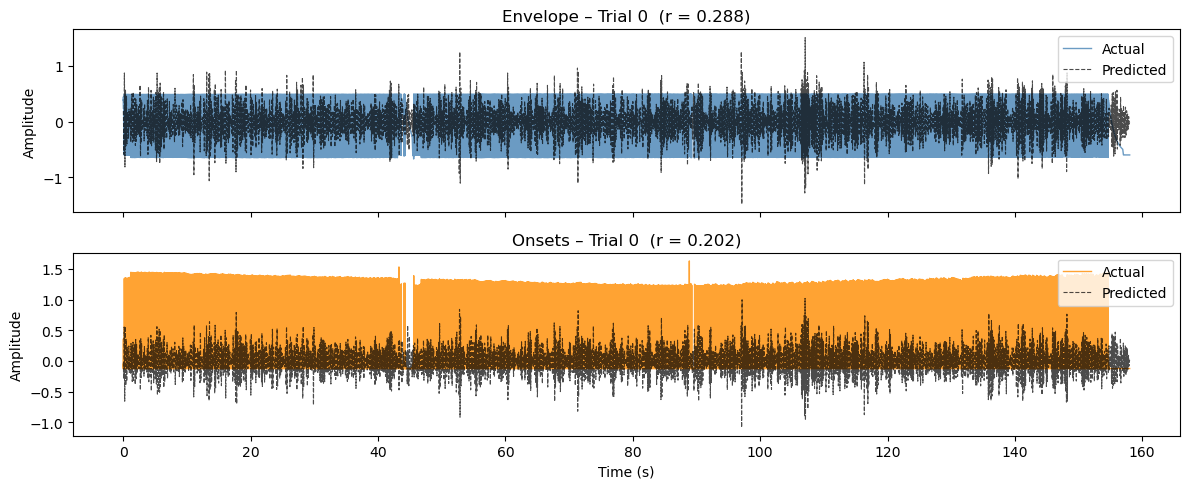

In [24]:
# # ── 1. Load data ──────────────────────────────────────────────────────────────
trials = data['trials']
n_trials = len(trials)

# ── 2. Extract per-trial correlations ─────────────────────────────────────────
r_envelope = []
r_onsets    = []

for trial_num in range(n_trials):
    trial = trials[f'trial{trial_num}']
    r_envelope.append(float(trial['r']))
    r_onsets.append(float(trial['r_onsets']))

r_envelope = np.array(r_envelope)
r_onsets   = np.array(r_onsets)

print(f"Envelope  | mean r = {r_envelope.mean():.3f}, std = {r_envelope.std():.3f}")
print(f"Onsets    | mean r = {r_onsets.mean():.3f},   std = {r_onsets.std():.3f}")

# ── 3. Figure 1 – Per-trial correlation bar charts ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
trial_labels = [f"T{i}" for i in range(n_trials)]
x = np.arange(n_trials)

for ax, r_vals, label, color in zip(
        axes,
        [r_envelope, r_onsets],
        ['Envelope', 'Onsets'],
        ['steelblue', 'darkorange']):
    bars = ax.bar(x, r_vals, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axhline(r_vals.mean(), color='black', linewidth=1.5, linestyle='--',
               label=f'Mean r = {r_vals.mean():.3f}')
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_ylabel('Correlation (r)')
    ax.set_title(f'{label} – Prediction vs. Actual EEG')
    ax.legend()
    ax.set_ylim(min(r_vals.min() - 0.05, -0.05), r_vals.max() + 0.05)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(trial_labels, rotation=45, ha='right', fontsize=8)
plt.tight_layout()
# plt.savefig('trial_correlations.png', dpi=150)
plt.show()

# ── 4. Figure 2 – Distribution of correlations ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, r_vals, label, color in zip(
        axes,
        [r_envelope, r_onsets],
        ['Envelope', 'Onsets'],
        ['steelblue', 'darkorange']):
    ax.hist(r_vals, bins=10, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(r_vals.mean(), color='black', linestyle='--',
               label=f'Mean = {r_vals.mean():.3f}')
    ax.axvline(np.median(r_vals), color='red', linestyle=':',
               label=f'Median = {np.median(r_vals):.3f}')
    ax.set_xlabel('Correlation (r)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Correlation Distribution')
    ax.legend()

plt.tight_layout()
# plt.savefig('correlation_distributions.png', dpi=150)
plt.show()

# ── 5. Figure 3 – Envelope vs. Onsets scatter ────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(r_envelope, r_onsets, color='purple', alpha=0.7, edgecolors='white', s=60)

# Annotate outlier trials (bottom 20% of either measure)
threshold_env = np.percentile(r_envelope, 20)
threshold_ons = np.percentile(r_onsets, 20)
for i, (re, ro) in enumerate(zip(r_envelope, r_onsets)):
    if re < threshold_env or ro < threshold_ons:
        ax.annotate(f'T{i}', (re, ro), fontsize=7, color='gray')

# Diagonal reference line
lims = [min(r_envelope.min(), r_onsets.min()) - 0.02,
        max(r_envelope.max(), r_onsets.max()) + 0.02]
ax.plot(lims, lims, 'k--', alpha=0.4, label='y = x')
ax.set_xlabel('Envelope r')
ax.set_ylabel('Onsets r')
ax.set_title('Envelope vs. Onsets Prediction Correlation')
ax.legend()
plt.tight_layout()
# plt.savefig('envelope_vs_onsets_scatter.png', dpi=150)
plt.show()

# ── 6. Figure 4 – Example trial: predicted vs. actual time series ─────────────
example_trial = trials['trial0']

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

for ax, y, y_pred, label, color in zip(
        axes,
        [example_trial['y'],      example_trial['y_onsets']],
        [example_trial['y_pred'], example_trial['y_pred_onsets']],
        ['Envelope', 'Onsets'],
        ['steelblue', 'darkorange']):
    
    # Convert eelbrain NDVar to numpy for plotting
    t     = y.time.times
    y_np  = y.get_data('time')
    yp_np = y_pred.get_data('time')

    ax.plot(t, y_np,  color=color,   alpha=0.8, linewidth=1,   label='Actual')
    ax.plot(t, yp_np, color='black', alpha=0.7, linewidth=0.8, linestyle='--', label='Predicted')
    ax.set_ylabel('Amplitude')
    r_val = float(example_trial['r'] if label == 'Envelope' else example_trial['r_onsets'])
    ax.set_title(f'{label} – Trial 0  (r = {r_val:.3f})')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
# plt.savefig('example_trial_timeseries.png', dpi=150)
plt.show()

## Plotting Musician vs Non-Musician correlation coefficients

#### Replicating experiments by Zorka Bozilovic (https://github.com/ZorkaBozilovic/audio-brain-decoding/tree/main)
<i>Please note: the TRF model was run over the Theta Band (4 - 8 Hz)</i>


In [4]:
# Initialize storage for r values by subject
r_values = {f'sub{i}': [] for i in range(1, 21)}
r_onsets_values = {f'sub{i}': [] for i in range(1, 21)}

# Load all files

for sub in range(1, 21):
   filename = f"pickles/Sub{sub}_['envelope', 'onsets', 'surprisal', 'entropy']_all_data.pkl"
   data = eelbrain.load.unpickle(filename)
   
   # Extract r values from all trials
   for trial_key in data['trials']:
       r_onsets = data['trials'][trial_key]['r_onsets']
       r_onsets_values[f'sub{sub}'].append(r_onsets)
       
       r = data['trials'][trial_key]['r']
       r_values[f'sub{sub}'].append(r)

In [5]:
# Separate musicians and non-musicians
non_musicians = [f'sub{i}' for i in range(1, 11)]
musicians = [f'sub{i}' for i in range(11, 21)]

# Aggregate the r-values for each group (musician / non musician) 
nm_vals = []
m_vals = []

for sub in non_musicians:
    nm_vals.extend(r_values[sub])
for sub in musicians:
    m_vals.extend(r_values[sub])
# Calculate t-tests and store p-values 

# Tells you whether there is a statistically significant difference between the two groups (musicians vs non-musicians) in terms of their r-values.
if nm_vals and m_vals:
    t_stat_musician, p_value_musician = stats.ttest_ind(nm_vals, m_vals)
    
print('p_value_musician:', p_value_musician)

p_value_musician: 1.0403596985370757e-09


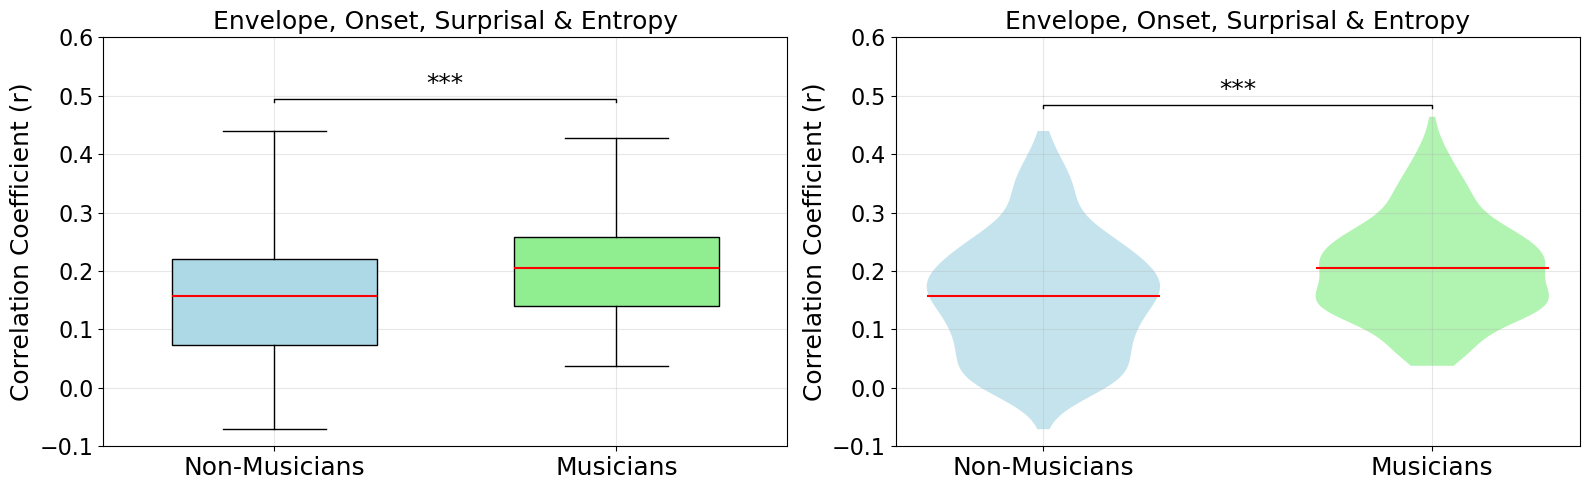

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_musician_boxplot(axes[0], nm_vals, m_vals, p_value_musician, ylabel='Correlation Coefficient (r)')
axes[0].set_title('Envelope, Onset, Surprisal & Entropy', fontsize=18)

plot_musician_violin(axes[1], nm_vals, m_vals, p_value_musician, ylabel='Correlation Coefficient (r)')
axes[1].set_title('Envelope, Onset, Surprisal & Entropy', fontsize=18)

# Encoding Correlation Analysis


## Analyze the results of one subject

Encoding CV r      | mean = 0.031, std = 0.021
Encoding CV r_rank | mean = 0.094, std = 0.038


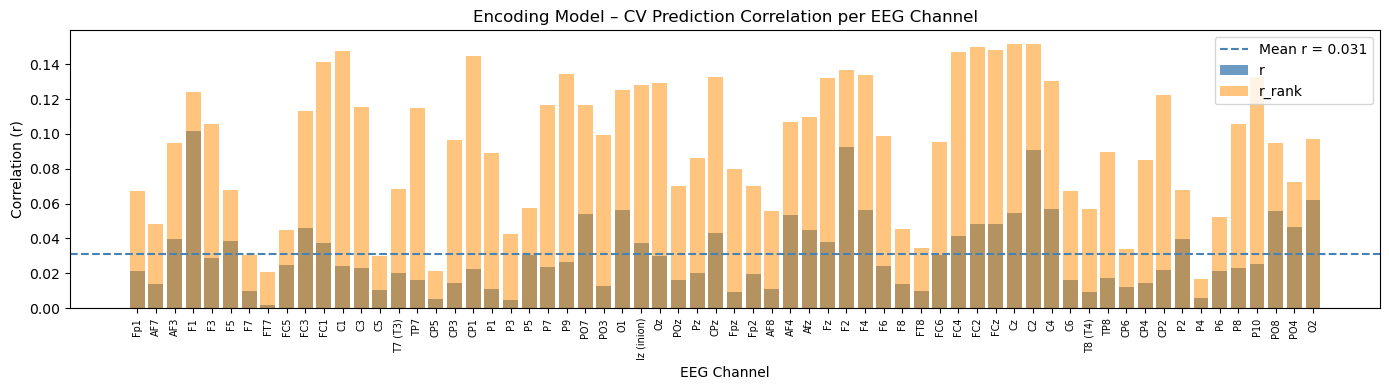

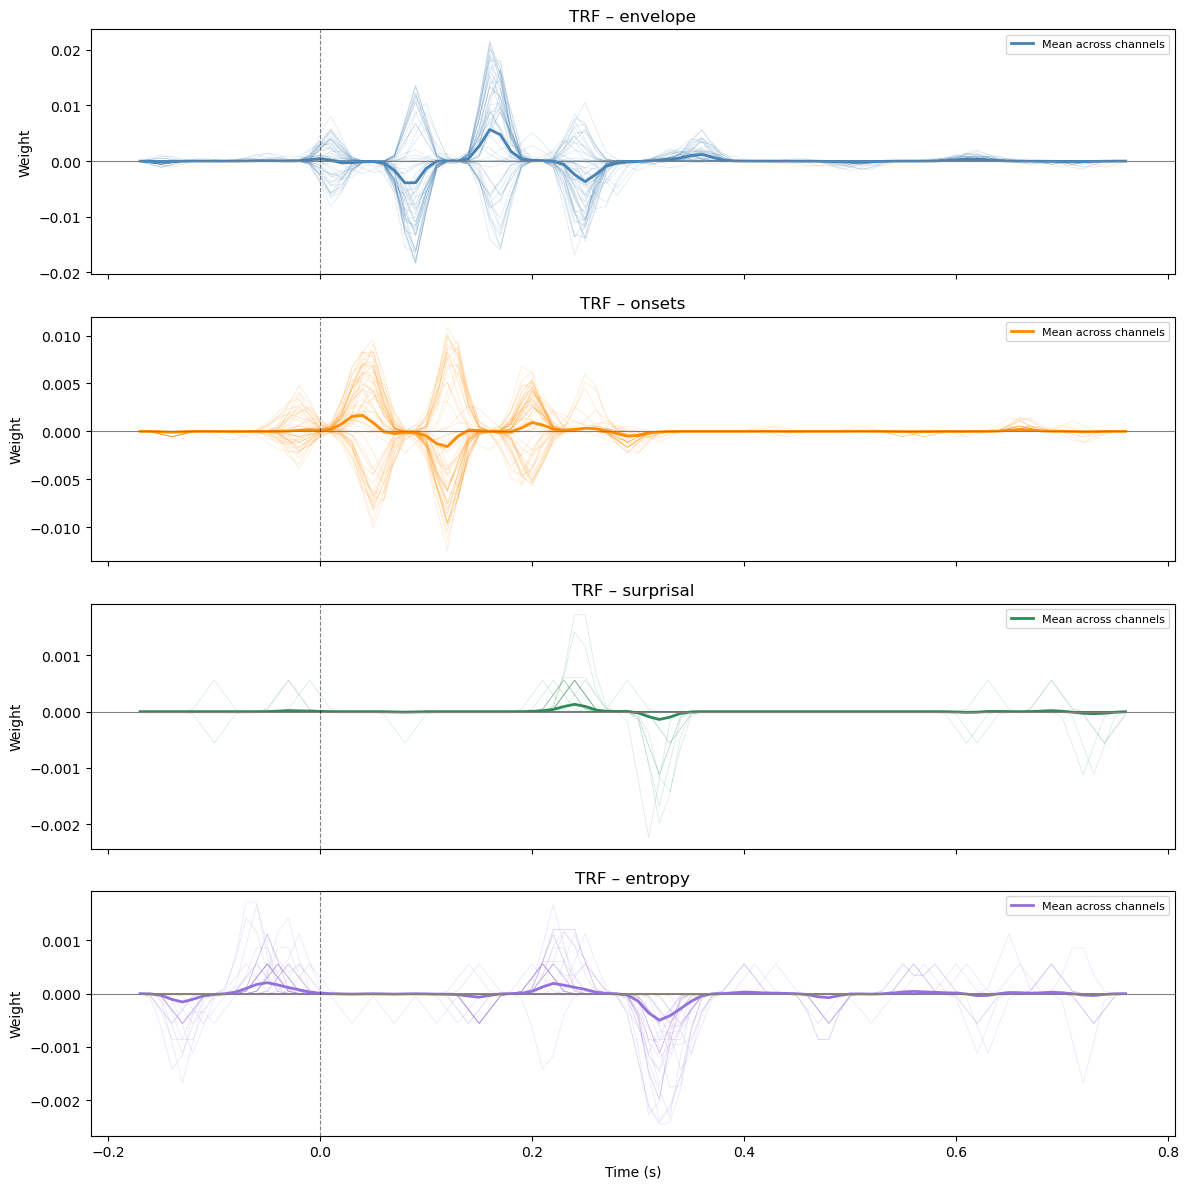

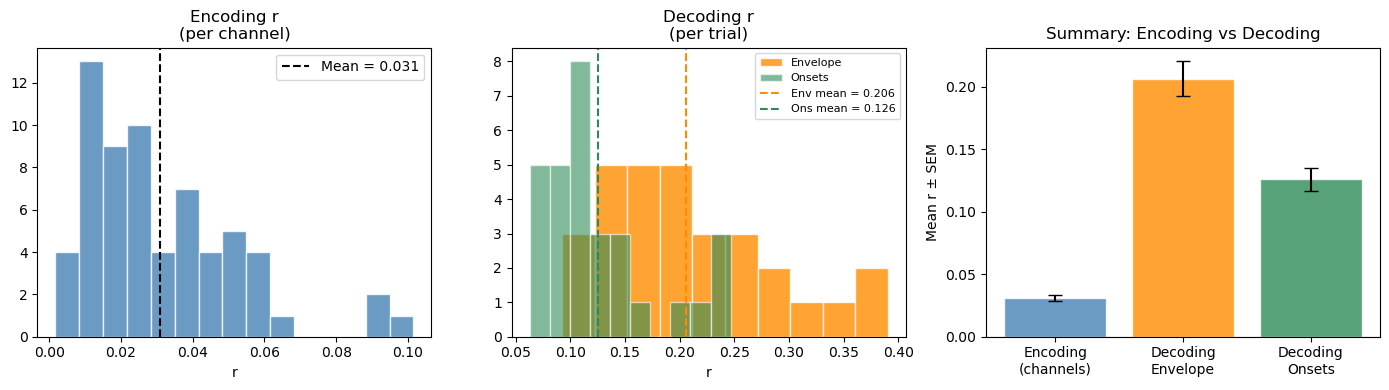

In [26]:
# ── 1. Load data ──────────────────────────────────────────────────────────────
filename = f"pickles/Sub19_['envelope', 'onsets', 'surprisal', 'entropy']_all_data.pkl"
all_data = eelbrain.load.unpickle(filename)

trf    = all_data['trf']
trf_cv = all_data['trf_cv']
trials = all_data['trials']  # your original decoding trials

x = ['envelope', 'onsets', 'surprisal', 'entropy']
n_trials = len(trials)

# ── 2. Extract encoding stats from trf_cv ────────────────────────────────────
# These are already computed inside the boosting object — no re-running needed
encoding_r      = trf_cv.r        # NDVar: CV correlation per EEG channel
encoding_r_rank = trf_cv.r_rank   # NDVar: rank correlation per EEG channel

print(f"Encoding CV r      | mean = {float(encoding_r.mean()):.3f}, std = {float(encoding_r.std()):.3f}")
print(f"Encoding CV r_rank | mean = {float(encoding_r_rank.mean()):.3f}, std = {float(encoding_r_rank.std()):.3f}")

# ── 3. Extract TRF weights per predictor ─────────────────────────────────────
trf_weights = {predictor: trf.h[i] for i, predictor in enumerate(x)}

# ── 4. Extract decoding correlations (unchanged from before) ─────────────────
r_envelope = np.array([float(trials[f'trial{i}']['r'])        for i in range(n_trials)])
r_onsets   = np.array([float(trials[f'trial{i}']['r_onsets']) for i in range(n_trials)])

# ── 5. Figure 1 – Encoding r per EEG channel ─────────────────────────────────
encoding_r_np      = encoding_r.get_data('sensor')
encoding_r_rank_np = encoding_r_rank.get_data('sensor')
channel_labels     = encoding_r.sensor.names  # actual channel names

fig, ax = plt.subplots(figsize=(14, 4))
x_pos = np.arange(len(encoding_r_np))
ax.bar(x_pos, encoding_r_np,      color='steelblue',  alpha=0.8, label='r')
ax.bar(x_pos, encoding_r_rank_np, color='darkorange', alpha=0.5, label='r_rank')
ax.axhline(encoding_r_np.mean(), color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Mean r = {encoding_r_np.mean():.3f}')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(channel_labels, rotation=90, fontsize=7)
ax.set_xlabel('EEG Channel')
ax.set_ylabel('Correlation (r)')
ax.set_title('Encoding Model – CV Prediction Correlation per EEG Channel')
ax.legend()
plt.tight_layout()
# plt.savefig('encoding_r_per_channel.png', dpi=150)
plt.show()

# ── 6. Figure 2 – TRF weights per predictor ──────────────────────────────────
fig, axes = plt.subplots(len(x), 1, figsize=(12, 3 * len(x)), sharex=True)
colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

for ax, predictor, color in zip(axes, x, colors):
    h    = trf_weights[predictor]
    t    = h.time.times
    # If h has a sensor dim, average across channels; otherwise use as-is
    h_np = h.get_data('time') if h.ndim == 1 else h.get_data(('sensor', 'time')).mean(0)
    # Also plot per-channel traces faintly if multi-channel
    if h.ndim > 1:
        h_all = h.get_data(('sensor', 'time'))
        for ch in h_all:
            ax.plot(t, ch, color=color, linewidth=0.5, alpha=0.2)
    ax.plot(t, h_np, color=color, linewidth=2, label='Mean across channels')
    ax.axhline(0, color='gray',  linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_ylabel('Weight')
    ax.set_title(f'TRF – {predictor}')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
# plt.savefig('trf_weights.png', dpi=150)
plt.show()

# ── 7. Figure 3 – Encoding vs Decoding: separate aligned comparisons ──────────
# Fix: encoding_r is per-channel, decoding r is per-trial — can't scatter directly.
# Instead: show distributions side by side for a meaningful comparison.

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel A: Encoding r distribution across channels
axes[0].hist(encoding_r_np, bins=15, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(encoding_r_np.mean(), color='black', linestyle='--',
                label=f'Mean = {encoding_r_np.mean():.3f}')
axes[0].set_xlabel('r')
axes[0].set_title('Encoding r\n(per channel)')
axes[0].legend()

# Panel B: Decoding r distribution across trials
axes[1].hist(r_envelope, bins=10, color='darkorange', alpha=0.8,
             edgecolor='white', label='Envelope')
axes[1].hist(r_onsets,   bins=10, color='seagreen',   alpha=0.6,
             edgecolor='white', label='Onsets')
axes[1].axvline(r_envelope.mean(), color='darkorange', linestyle='--',
                label=f'Env mean = {r_envelope.mean():.3f}')
axes[1].axvline(r_onsets.mean(),   color='seagreen',   linestyle='--',
                label=f'Ons mean = {r_onsets.mean():.3f}')
axes[1].set_xlabel('r')
axes[1].set_title('Decoding r\n(per trial)')
axes[1].legend(fontsize=8)

# Panel C: Summary bar — mean r for encoding vs both decoding directions
means  = [encoding_r_np.mean(), r_envelope.mean(), r_onsets.mean()]
sems   = [encoding_r_np.std() / np.sqrt(len(encoding_r_np)),
          r_envelope.std()   / np.sqrt(len(r_envelope)),
          r_onsets.std()     / np.sqrt(len(r_onsets))]
labels = ['Encoding\n(channels)', 'Decoding\nEnvelope', 'Decoding\nOnsets']
bar_colors = ['steelblue', 'darkorange', 'seagreen']

axes[2].bar(labels, means, yerr=sems, color=bar_colors, alpha=0.8,
            edgecolor='white', capsize=5)
axes[2].axhline(0, color='gray', linewidth=0.8)
axes[2].set_ylabel('Mean r ± SEM')
axes[2].set_title('Summary: Encoding vs Decoding')

plt.tight_layout()
# plt.savefig('encoding_vs_decoding.png', dpi=150)
plt.show()

## Analyze the difference between training the model on envelope only vs. envelope + onset + surprisal + entropy for one subject

Acoustic model | mean r = 0.031, std = 0.021
Full model     | mean r = 0.031,     std = 0.021
Mean improvement (full - acoustic): -0.000


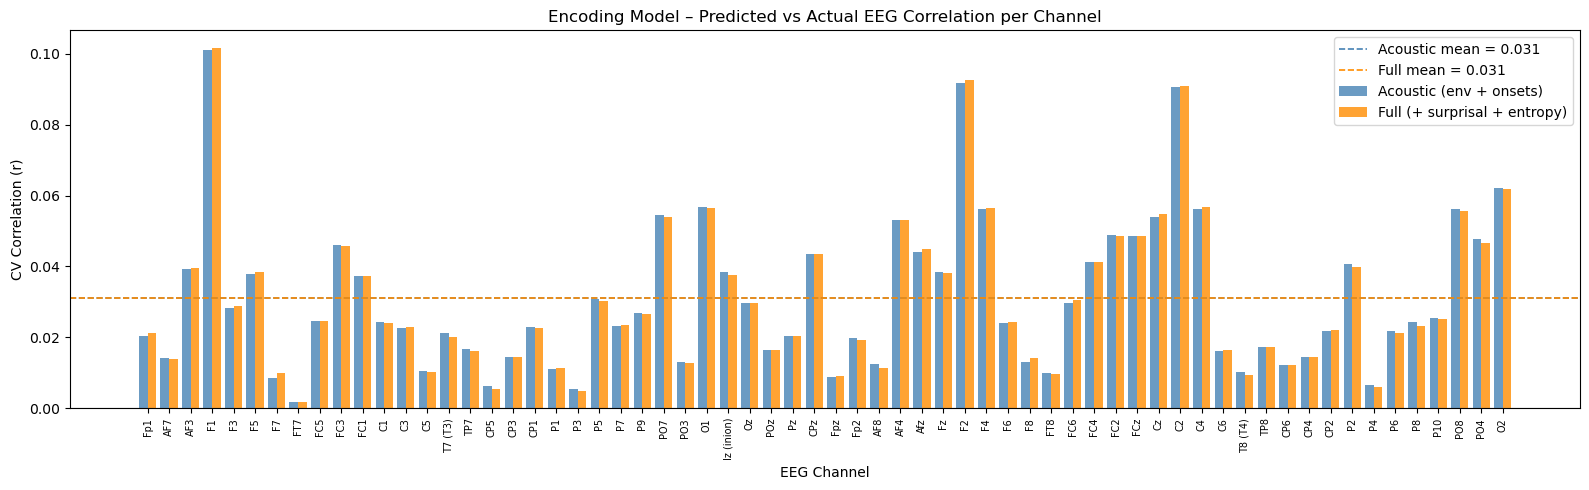

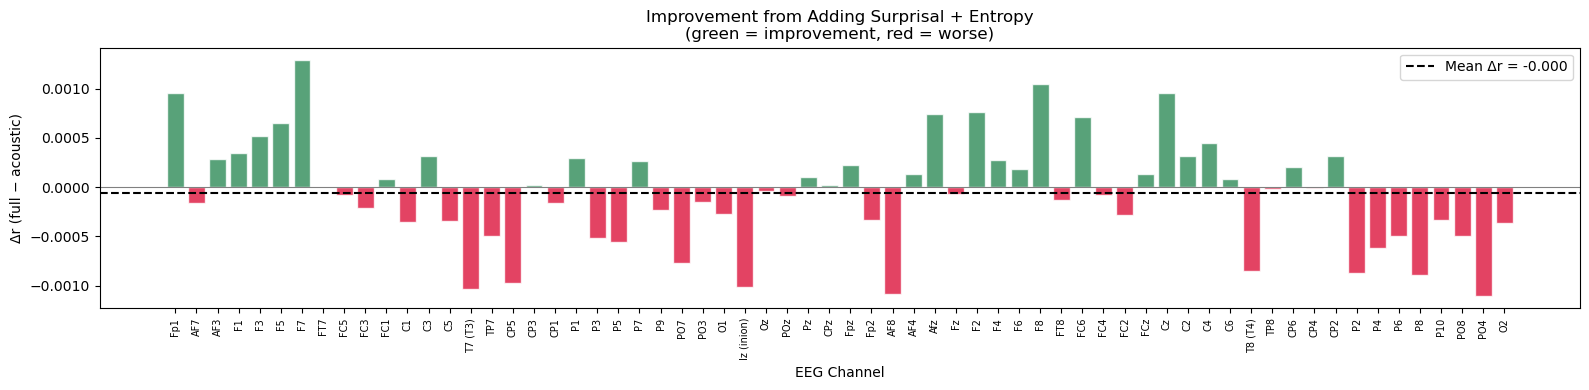

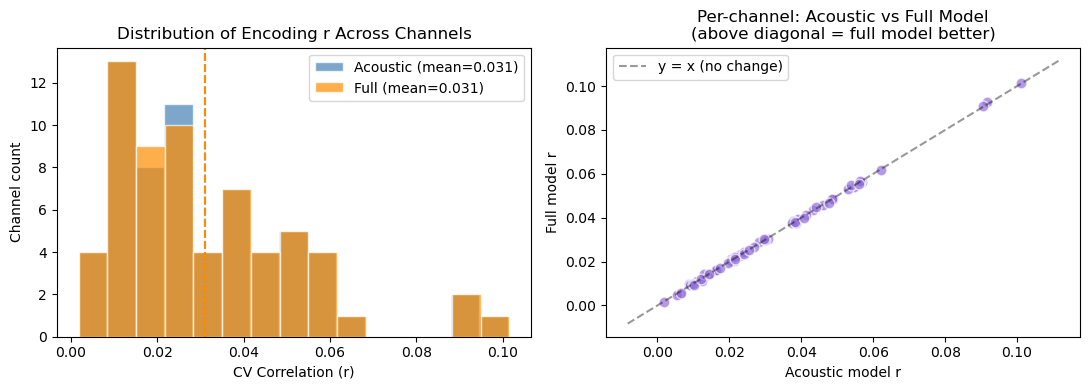

In [32]:
import eelbrain
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load both pickle files ─────────────────────────────────────────────────
data_acoustic = eelbrain.load.unpickle("pickles/Sub19_['envelope']_all_data.pkl")
data_full     = eelbrain.load.unpickle("pickles/Sub19_['envelope', 'onsets', 'surprisal', 'entropy']_all_data.pkl")

trf_cv_acoustic = data_acoustic['trf_cv']
trf_cv_full     = data_full['trf_cv']

# ── 2. Extract encoding r per channel from trf_cv ────────────────────────────
# trf_cv.r is the cross-validated correlation between predicted and actual EEG
# This IS the encoding correlation — no additional computation needed
r_acoustic = trf_cv_acoustic.r.get_data('sensor')  # shape: (n_channels,)
r_full     = trf_cv_full.r.get_data('sensor')

channel_names = trf_cv_acoustic.r.sensor.names

print(f"Acoustic model | mean r = {r_acoustic.mean():.3f}, std = {r_acoustic.std():.3f}")
print(f"Full model     | mean r = {r_full.mean():.3f},     std = {r_full.std():.3f}")
print(f"Mean improvement (full - acoustic): {(r_full - r_acoustic).mean():.3f}")

# ── 3. Figure 1 – Encoding r per channel, both models ────────────────────────
x_pos = np.arange(len(channel_names))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x_pos - width/2, r_acoustic, width, color='steelblue',  alpha=0.8, label='Acoustic (env + onsets)')
ax.bar(x_pos + width/2, r_full,     width, color='darkorange', alpha=0.8, label='Full (+ surprisal + entropy)')
ax.axhline(r_acoustic.mean(), color='steelblue',  linestyle='--', linewidth=1.2,
           label=f'Acoustic mean = {r_acoustic.mean():.3f}')
ax.axhline(r_full.mean(),     color='darkorange', linestyle='--', linewidth=1.2,
           label=f'Full mean = {r_full.mean():.3f}')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(channel_names, rotation=90, fontsize=7)
ax.set_xlabel('EEG Channel')
ax.set_ylabel('CV Correlation (r)')
ax.set_title('Encoding Model – Predicted vs Actual EEG Correlation per Channel')
ax.legend()
plt.tight_layout()
# plt.savefig('encoding_r_both_models.png', dpi=150)
plt.show()

# ── 4. Figure 2 – Difference in r (full - acoustic) per channel ───────────────
r_diff = r_full - r_acoustic

fig, ax = plt.subplots(figsize=(16, 4))
colors = ['seagreen' if d > 0 else 'crimson' for d in r_diff]
ax.bar(x_pos, r_diff, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(0,           color='gray',  linewidth=0.8)
ax.axhline(r_diff.mean(), color='black', linewidth=1.5, linestyle='--',
           label=f'Mean Δr = {r_diff.mean():.3f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(channel_names, rotation=90, fontsize=7)
ax.set_xlabel('EEG Channel')
ax.set_ylabel('Δr (full − acoustic)')
ax.set_title('Improvement from Adding Surprisal + Entropy\n(green = improvement, red = worse)')
ax.legend()
plt.tight_layout()
# plt.savefig('encoding_r_difference.png', dpi=150)
plt.show()

# ── 5. Figure 3 – Distribution + summary ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel A: Overlapping histograms
axes[0].hist(r_acoustic, bins=15, color='steelblue',  alpha=0.7,
             edgecolor='white', label=f'Acoustic (mean={r_acoustic.mean():.3f})')
axes[0].hist(r_full,     bins=15, color='darkorange', alpha=0.7,
             edgecolor='white', label=f'Full (mean={r_full.mean():.3f})')
axes[0].axvline(r_acoustic.mean(), color='steelblue',  linestyle='--', linewidth=1.5)
axes[0].axvline(r_full.mean(),     color='darkorange', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('CV Correlation (r)')
axes[0].set_ylabel('Channel count')
axes[0].set_title('Distribution of Encoding r Across Channels')
axes[0].legend()

# Panel B: Scatter — acoustic r vs full r per channel
axes[1].scatter(r_acoustic, r_full, color='mediumpurple', alpha=0.7,
                edgecolors='white', s=60)
lims = [min(r_acoustic.min(), r_full.min()) - 0.01,
        max(r_acoustic.max(), r_full.max()) + 0.01]
axes[1].plot(lims, lims, 'k--', alpha=0.4, label='y = x (no change)')
axes[1].set_xlabel('Acoustic model r')
axes[1].set_ylabel('Full model r')
axes[1].set_title('Per-channel: Acoustic vs Full Model\n(above diagonal = full model better)')
axes[1].legend()

plt.tight_layout()
# plt.savefig('encoding_r_comparison.png', dpi=150)
plt.show()

Paired t-test: t = 0.887, p = 0.3783 ns
Mean Δr (full − acoustic) = -0.0001


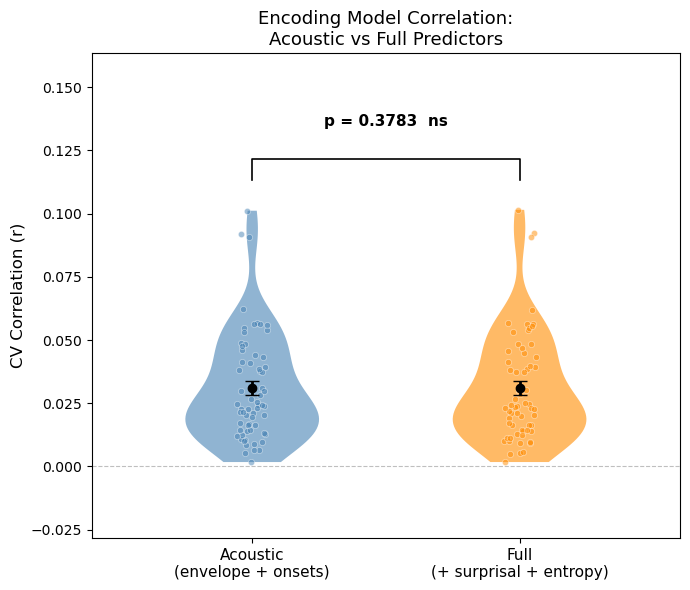

In [33]:
from scipy import stats

# ── Data ─────────────────────────────────────────────────────────────────────
r_acoustic = trf_cv_acoustic.r.get_data('sensor')
r_full     = trf_cv_full.r.get_data('sensor')

# ── Statistics ───────────────────────────────────────────────────────────────
# Paired t-test: same channels compared across models
t_stat, p_val = stats.ttest_rel(r_acoustic, r_full)
mean_diff = (r_full - r_acoustic).mean()

# Significance label
if p_val < 0.001:
    sig_label = '***'
elif p_val < 0.01:
    sig_label = '**'
elif p_val < 0.05:
    sig_label = '*'
else:
    sig_label = 'ns'

print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f} {sig_label}")
print(f"Mean Δr (full − acoustic) = {mean_diff:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

data   = [r_acoustic, r_full]
labels = ['Acoustic\n(envelope + onsets)', 'Full\n(+ surprisal + entropy)']
colors = ['steelblue', 'darkorange']

# Violin
parts = ax.violinplot(data, positions=[1, 2], showmedians=False, showextrema=False)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

# Overlay individual channel points (jittered)
for i, (d, color) in enumerate(zip(data, colors), start=1):
    jitter = np.random.uniform(-0.06, 0.06, size=len(d))
    ax.scatter(i + jitter, d, color=color, alpha=0.5, s=20, edgecolors='white', linewidths=0.5)

# Mean ± SEM markers
for i, d in enumerate(data, start=1):
    ax.errorbar(i, d.mean(), yerr=d.std() / np.sqrt(len(d)),
                fmt='o', color='black', markersize=6, capsize=5, linewidth=2, zorder=5)

# ── Significance bracket ──────────────────────────────────────────────────────
y_max    = max(r_acoustic.max(), r_full.max())
y_bracket = y_max + 0.02
y_text    = y_bracket + 0.012

ax.plot([1, 1, 2, 2], [y_bracket - 0.008, y_bracket, y_bracket, y_bracket - 0.008],
        color='black', linewidth=1.2)
ax.text(1.5, y_text, f'p = {p_val:.4f}  {sig_label}',
        ha='center', va='bottom', fontsize=11, fontweight='bold')

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xticks([1, 2])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('CV Correlation (r)', fontsize=12)
ax.set_title('Encoding Model Correlation:\nAcoustic vs Full Predictors', fontsize=13)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlim(0.4, 2.6)
ax.set_ylim(min(r_acoustic.min(), r_full.min()) - 0.03,
            y_text + 0.03)

plt.tight_layout()
plt.savefig('violin_acoustic_vs_full.png', dpi=150)
plt.show()

# Now analyze statistical significance using all subjects

  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level paired t-test (mean r across channels):
  t = 2.489,  p = 0.0222  *
  Mean Δr = -0.0003 ± 0.0001 SEM


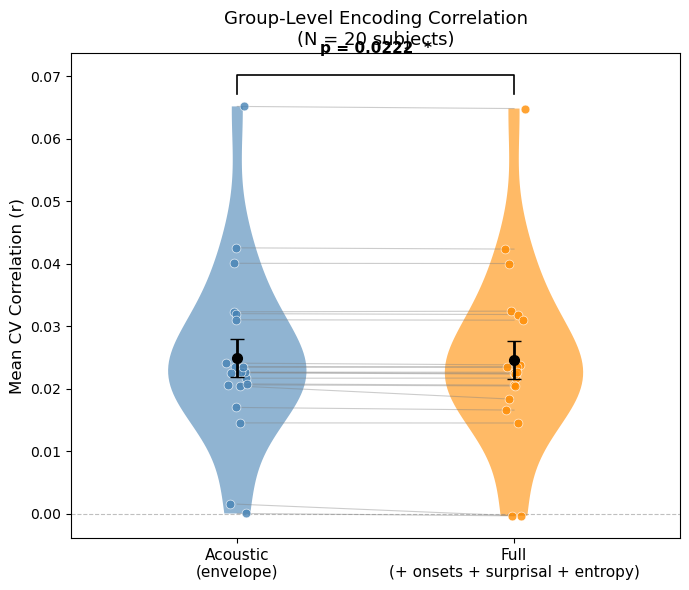

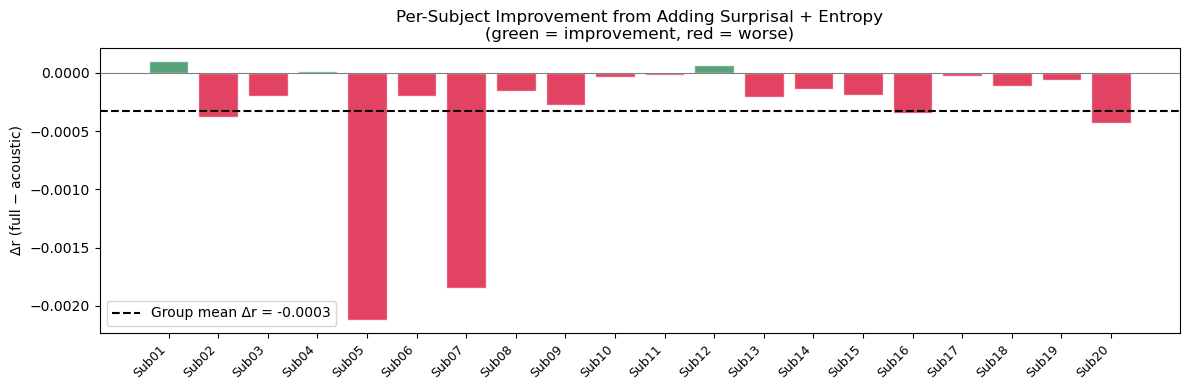

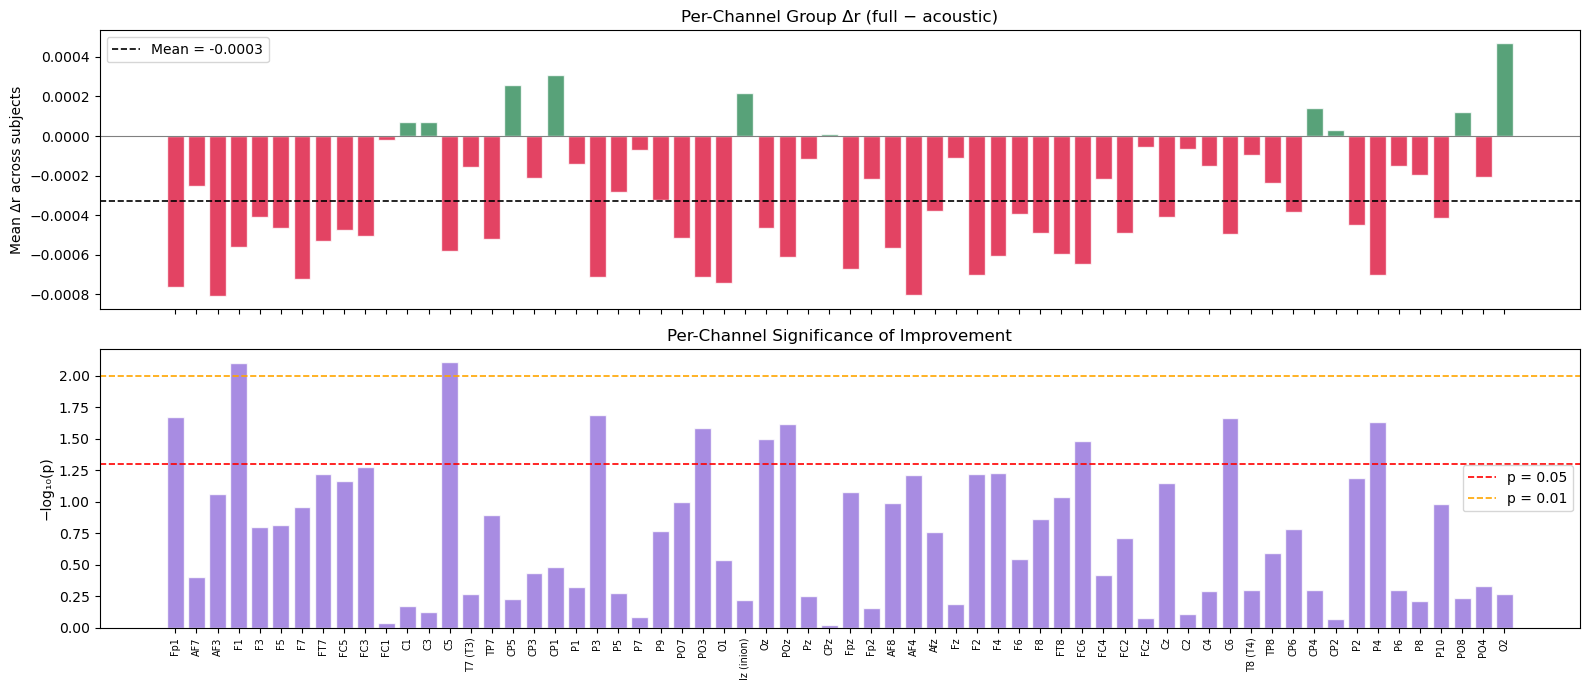

In [34]:
import eelbrain
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── 1. Load all subjects ──────────────────────────────────────────────────────
n_subjects = 20
r_acoustic_all = []  # will be shape (n_subjects, n_channels)
r_full_all     = []

for sub in range(1, n_subjects + 1):
    try:
        data_acoustic = eelbrain.load.unpickle(f"pickles/Sub{sub}_['envelope']_all_data.pkl")
        data_full     = eelbrain.load.unpickle(f"pickles/Sub{sub}_['envelope', 'onsets', 'surprisal', 'entropy']_all_data.pkl")

        r_acoustic_all.append(data_acoustic['trf_cv'].r.get_data('sensor'))
        r_full_all.append(data_full['trf_cv'].r.get_data('sensor'))
        print(f"  Sub{sub:02d} loaded")

    except FileNotFoundError:
        print(f"  Sub{sub:02d} missing — skipping")

r_acoustic_all = np.array(r_acoustic_all)  # (n_subjects, n_channels)
r_full_all     = np.array(r_full_all)
n_subjects     = len(r_acoustic_all)       # update in case any were skipped

print(f"\nLoaded {n_subjects} subjects, {r_acoustic_all.shape[1]} channels each")

# ── 2. Per-subject mean r (averaged across channels) ─────────────────────────
r_acoustic_per_sub = r_acoustic_all.mean(axis=1)  # (n_subjects,)
r_full_per_sub     = r_full_all.mean(axis=1)
r_diff_per_sub     = r_full_per_sub - r_acoustic_per_sub

# ── 3. Group-level statistics ─────────────────────────────────────────────────
# One-sample t-test on Δr: is the mean improvement across subjects > 0?
t_stat, p_val = stats.ttest_rel(r_acoustic_per_sub, r_full_per_sub)
mean_diff      = r_diff_per_sub.mean()
sem_diff       = r_diff_per_sub.std() / np.sqrt(n_subjects)

# Per-channel group test (paired t-test across subjects at each channel)
n_channels    = r_acoustic_all.shape[1]
t_per_channel = np.zeros(n_channels)
p_per_channel = np.zeros(n_channels)
for ch in range(n_channels):
    t_per_channel[ch], p_per_channel[ch] = stats.ttest_rel(
        r_acoustic_all[:, ch], r_full_all[:, ch]
    )

sig_label = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
print(f"\nGroup-level paired t-test (mean r across channels):")
print(f"  t = {t_stat:.3f},  p = {p_val:.4f}  {sig_label}")
print(f"  Mean Δr = {mean_diff:.4f} ± {sem_diff:.4f} SEM")

# ── 4. Figure 1 – Violin: group-level acoustic vs full ───────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

data   = [r_acoustic_per_sub, r_full_per_sub]
labels = ['Acoustic\n(envelope)', 'Full\n(+ onsets + surprisal + entropy)']
colors = ['steelblue', 'darkorange']

parts = ax.violinplot(data, positions=[1, 2], showmedians=False, showextrema=False)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

# Individual subject points connected by lines
for i in range(n_subjects):
    ax.plot([1, 2], [r_acoustic_per_sub[i], r_full_per_sub[i]],
            color='gray', alpha=0.4, linewidth=0.8)
for i, (d, color) in enumerate(zip(data, colors), start=1):
    jitter = np.random.uniform(-0.04, 0.04, size=len(d))
    ax.scatter(i + jitter, d, color=color, s=40, alpha=0.8,
               edgecolors='white', linewidths=0.5, zorder=4)

# Mean ± SEM
for i, d in enumerate(data, start=1):
    ax.errorbar(i, d.mean(), yerr=d.std() / np.sqrt(len(d)),
                fmt='o', color='black', markersize=7, capsize=5, linewidth=2, zorder=5)

# Significance bracket
y_bracket = max(r_acoustic_per_sub.max(), r_full_per_sub.max()) + 0.005
ax.plot([1, 1, 2, 2], [y_bracket - 0.003, y_bracket, y_bracket, y_bracket - 0.003],
        color='black', linewidth=1.2)
ax.text(1.5, y_bracket + 0.003, f'p = {p_val:.4f}  {sig_label}',
        ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks([1, 2])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Mean CV Correlation (r)', fontsize=12)
ax.set_title(f'Group-Level Encoding Correlation\n(N = {n_subjects} subjects)', fontsize=13)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlim(0.4, 2.6)
plt.tight_layout()
plt.savefig('group_violin.png', dpi=150)
plt.show()

# ── 5. Figure 2 – Per-subject Δr bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
sub_labels = [f'Sub{i+1:02d}' for i in range(n_subjects)]
colors_bar = ['seagreen' if d > 0 else 'crimson' for d in r_diff_per_sub]

ax.bar(range(n_subjects), r_diff_per_sub, color=colors_bar, alpha=0.8, edgecolor='white')
ax.axhline(0,              color='gray',  linewidth=0.8)
ax.axhline(mean_diff,      color='black', linewidth=1.5, linestyle='--',
           label=f'Group mean Δr = {mean_diff:.4f}')
ax.set_xticks(range(n_subjects))
ax.set_xticklabels(sub_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Δr (full − acoustic)')
ax.set_title('Per-Subject Improvement from Adding Surprisal + Entropy\n(green = improvement, red = worse)')
ax.legend()
plt.tight_layout()
plt.savefig('group_delta_r_per_subject.png', dpi=150)
plt.show()

# ── 6. Figure 3 – Per-channel group Δr with significance ─────────────────────
r_diff_per_channel = (r_full_all - r_acoustic_all).mean(axis=0)  # (n_channels,)
channel_names      = data_full['trf_cv'].r.sensor.names

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

# Top: mean Δr per channel
colors_ch = ['seagreen' if d > 0 else 'crimson' for d in r_diff_per_channel]
axes[0].bar(range(n_channels), r_diff_per_channel, color=colors_ch, alpha=0.8, edgecolor='white')
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].axhline(r_diff_per_channel.mean(), color='black', linestyle='--', linewidth=1.2,
                label=f'Mean = {r_diff_per_channel.mean():.4f}')
axes[0].set_ylabel('Mean Δr across subjects')
axes[0].set_title('Per-Channel Group Δr (full − acoustic)')
axes[0].legend()

# Bottom: -log10(p) per channel with significance threshold line
neg_log_p = -np.log10(p_per_channel)
axes[1].bar(range(n_channels), neg_log_p, color='mediumpurple', alpha=0.8, edgecolor='white')
axes[1].axhline(-np.log10(0.05), color='red',    linestyle='--', linewidth=1.2, label='p = 0.05')
axes[1].axhline(-np.log10(0.01), color='orange', linestyle='--', linewidth=1.2, label='p = 0.01')
axes[1].set_ylabel('−log₁₀(p)')
axes[1].set_title('Per-Channel Significance of Improvement')
axes[1].set_xticks(range(n_channels))
axes[1].set_xticklabels(channel_names, rotation=90, fontsize=7)
axes[1].legend()

plt.tight_layout()
plt.savefig('group_per_channel.png', dpi=150)
plt.show()